Figure S5: Local PC properties. A Variance explained by each PC phenotype for all genes split by whether or not the gene is in the cluster whose expression was used to calculate the PC. B Spearman correlation each PC to all other PCs for all cultured fibroblast PCs. 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
from scipy.stats import spearmanr


from tqdm.auto import tqdm 
tqdm.pandas()

prefix = '/home/klawren/oak/pcqtls'
import yaml
config_path= f'{prefix}/config_old/main_pcqtl.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

import sys
sys.path.append('/home/klawren/oak/pcqtls/workflow/scripts')
from utils import *
from annotate_clusters import * 


%config InlineBackend.figure_formats = ['png']
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
plt.rcParams.update({'font.size': 7})

/home/klawren/.pixi/envs/python/lib/python3.12/site-packages/sorted_nearest/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [ ]:
pc_df = load_pc(config, my_tissue_id).reset_index(drop=True)

# local pc correlations to one another 
pc_corr_values = []
for chr_id, pc_chr_df in pc_df.groupby('#chr'):
    pc_corr, pc_pvalue = spearmanr(pc_chr_df[pc_chr_df.columns[pc_chr_df.columns.str.contains('GTEX')]], axis=1)
    pc_corr_df = pd.DataFrame(pc_corr)
    upper_triangle_indices = np.triu_indices_from(pc_corr_df, k=1)  # k=1 excludes the diagonal
    upper_triangle_values = pc_corr_df.values[upper_triangle_indices]
    pc_corr_values.extend(upper_triangle_values.tolist())


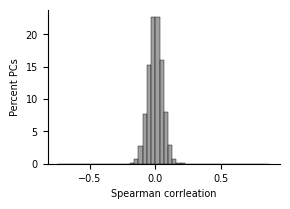

In [ ]:
fig, ax = plt.subplots(figsize=(3,2))
sns.histplot(pc_corr_values, bins=50, color='grey', stat='percent')
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlabel("Spearman corrleation")
ax.set_ylabel("Percent PCs")
plt.savefig("/home/klawren/oak/pcqtls/workflow/supplemental_figures/figures/figure_s5_b.pdf", transparent=True)
plt.show()

In [ ]:
# load in expression and covariates data
covariates_df = pd.read_csv('{}/{}/{}.v8.covariates.txt'.format(prefix, config['covariates_dir'], my_tissue_id), sep='\t', index_col=0).T
expression_df = load_expression(config, my_tissue_id)

residal_exp = calculate_residual(expression_df[covariates_df.index], covariates_df, center=True)
residal_exp = pd.DataFrame(residal_exp, columns=covariates_df.index, index=expression_df['gene_id'])
residal_exp.reset_index(inplace=True)


In [ ]:
# faster version
def get_global_pc_variances(pc_df, residal_exp):
    sample_ids = pc_df.columns[pc_df.columns.str.contains('GTEX')]
    num_pc = len(pc_df)
    num_expression = len(residal_exp)
    global_variences = np.zeros((num_pc, num_expression))

    # Convert relevant DataFrames to numpy arrays for faster access
    pc_values_array = pc_df[sample_ids].astype('float').to_numpy()
    expression_values_array = residal_exp[sample_ids].astype('float').to_numpy()

    # Center the values by subtracting the mean
    pc_means = pc_values_array.mean(axis=1, keepdims=True)
    expression_means = expression_values_array.mean(axis=1, keepdims=True)

    # Compute standard deviations
    pc_std = pc_values_array.std(axis=1, keepdims=True)
    expression_std = expression_values_array.std(axis=1, keepdims=True)

    # Compute the global variances
    for pc_idx in tqdm(range(num_pc), total=num_pc):
        for expression_idx in range(num_expression):
            # Covariance calculation (using centered values)
            covariance = np.sum((pc_values_array[pc_idx] - pc_means[pc_idx]) * (expression_values_array[expression_idx] - expression_means[expression_idx]))
            r_num = covariance
            r_den = pc_std[pc_idx] * expression_std[expression_idx] * (len(sample_ids) - 1)  # normalization factor

            # Compute the squared correlation coefficient
            if r_den != 0:
                r_squared = (r_num / r_den) ** 2
            else:
                r_squared = 0  # if standard deviation is zero, set to 0 (no correlation)

            global_variences[pc_idx, expression_idx] = r_squared
    return global_variences

In [ ]:
# var exaplined by local pcs on residualized expression
global_variences = []
for chr_id, chr_pc_df in pc_df.groupby('#chr'):
    print(chr_id)
    chr_global_variences = get_global_pc_variances(chr_pc_df, residal_exp)
    # mask for if the value is in a cluster
    in_cluster_mask = np.zeros(chr_global_variences.shape)
    for i in range(len(residal_exp)):
        expression_row = residal_exp.iloc[i]
        in_cluster_mask[:,i] = chr_pc_df['gene_id'].str.contains(expression_row['gene_id'])
    global_variences.append(pd.DataFrame({'var_explained':chr_global_variences.flatten()*100, 'gene_type':in_cluster_mask.flatten()}))

global_variences_df = pd.concat(global_variences)


chr1


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 228/228 [01:56<00:00,  1.95it/s]


chr10


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 59/59 [00:29<00:00,  2.02it/s]


chr11


...

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 115/115 [00:58<00:00,  1.96it/s]


chr8


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 54/54 [00:27<00:00,  1.94it/s]


chr9


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 72/72 [00:35<00:00,  2.01it/s]


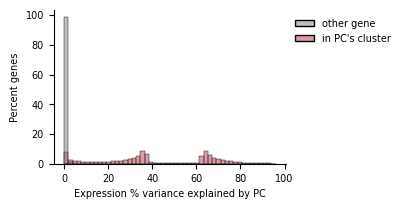

In [ ]:
fig, ax = plt.subplots(figsize=(3,2))

sns.histplot(global_variences_df, x='var_explained', bins=50, hue='gene_type', common_norm=False, stat='percent', palette=['grey', '#B83A4B'])

ax.spines[['top', 'right']].set_visible(False)
ax.set_xlabel('Expression % variance explained by PC')
ax.set_ylabel('Percent genes')

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), title='', labels=['other gene', "in PC's cluster"], frameon=False)
plt.savefig("/home/klawren/oak/pcqtls/workflow/supplemental_figures/figures/figure_s5_a.pdf", transparent=True)
plt.show()
